# Multi-scale

Can we link from our particle scale to the continuum?

In [1]:
import yaml
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

import layer_models

In [2]:
# This is extracted from the code we used to manage the big parameter sweep,
# so the input is a bit eccentric and split into things we (used to) sweep over
# and things we kept fixed for a whole sweep...

# Our 'sweep' parameters (highlighted point in Fig ):
case_name = 'test'
delta_t_icb = -10.0
delta_x_icb = 0.008125
this_i0 = None # Take it from the yaml

# Other model parameters as yaml:
input_data = """
f_layer_thickness : 200000
xfe_outer_core : 0.83
growth_prefactor : 150.0
i0 : 1.000000E-11
surf_energy : 1.08
wetting_angle : 5.0
number_of_analysis_points : 100
number_of_knots : 5
r_icb : 1221500
r_cmb : 3480000
gruneisen_parameter : 1.5
chemical_diffusivity : 1.000000E-09
kinematic_viscosity : 2.000000E-06
thermal_conductivity : 100.0
max_time : 1.0E20
hetrogeneous_radius : 10.0e-10
"""

input_params = yaml.load(input_data, yaml.CLoader)

In [3]:
# Note that if BV freq is imaginary, or the case fails to run, output_data will be None...
cases_dict, output_data = layer_models.run_case(case_name, delta_t_icb, delta_x_icb, this_i0, input_params)

Dt = -10.0, delta_x = 0.008125, BV freq = 0.00022213856443482763, dT_liq = 75.86190718940907, dT_cond = 58.15753496004072


/Users/andreww/Code/slurry/flayer.py:530: RuntimeWarning: invalid value encountered in divide
  mean_particle_velocities[i] = np.mean((partial_densities * partial_velocities) /


Heat from crystalisation = 6.283611874717909 TW
Oxygen production rate = 2.7409723667471587e-08 Tg/s
Oxygen enrichment rate of outer core = 4.694942116025412e-05 wt. % Oxygen / Ga
maximum particle radius = 0.033483329504512764 m
maximum solid fraction = 1.368185474684128e-10
max_nucleation_rate = 8.931855885205271e-12


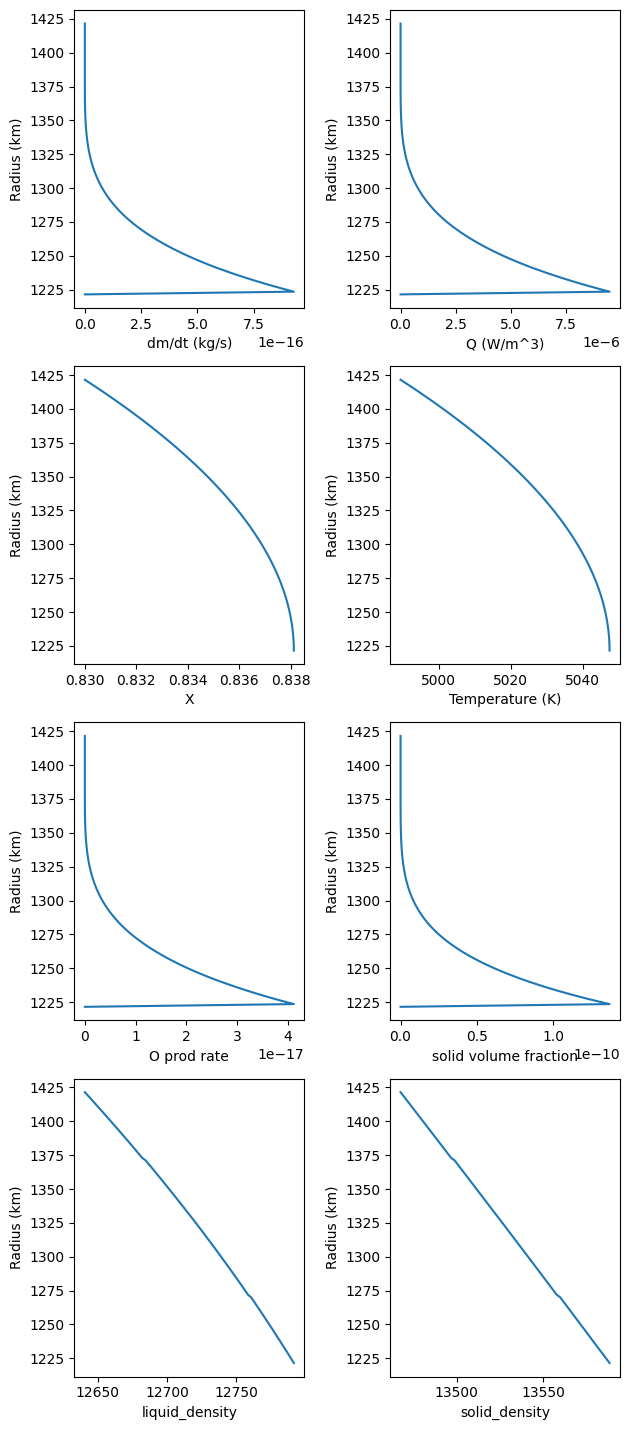

In [4]:
fig, axs = plt.subplots(ncols=2, nrows=4, figsize=(6.4, 4.8*3))

axs[0,0].plot(output_data["profiles"].mass_fraction_solid_production_rate, output_data["profiles"].radius/1000.0)
axs[0,0].set_xlabel("dm/dt (kg/s)")
axs[0,0].set_ylabel("Radius (km)")

axs[0,1].plot(output_data["profiles"].heat_production_rate, output_data["profiles"].radius/1000.0)
axs[0,1].set_xlabel("Q (W/m^3)")
axs[0,1].set_ylabel("Radius (km)")

axs[1,0].plot(output_data["profiles"].liquid_composition, output_data["profiles"].radius/1000.0)
axs[1,0].set_xlabel("X")
axs[1,0].set_ylabel("Radius (km)")

axs[1,1].plot(output_data["profiles"].temperature, output_data["profiles"].radius/1000.0)
axs[1,1].set_xlabel("Temperature (K)")
axs[1,1].set_ylabel("Radius (km)")

axs[2,0].plot(output_data["profiles"].o_prod_rate, output_data["profiles"].radius/1000.0)
axs[2,0].set_xlabel("O prod rate")
axs[2,0].set_ylabel("Radius (km)")

axs[2,1].plot(output_data["profiles"].solid_volume_fraction, output_data["profiles"].radius/1000.0)
axs[2,1].set_xlabel("solid volume fraction")
axs[2,1].set_ylabel("Radius (km)")

axs[3,0].plot(output_data["profiles"].liquid_density, output_data["profiles"].radius/1000.0)
axs[3,0].set_xlabel("liquid_density")
axs[3,0].set_ylabel("Radius (km)")

axs[3,1].plot(output_data["profiles"].solid_density, output_data["profiles"].radius/1000.0)
axs[3,1].set_xlabel("solid_density")
axs[3,1].set_ylabel("Radius (km)")

fig.tight_layout()
plt.show()

In [5]:
# EQ 2.1b

liquid_velocity = 0.0
liquid_velocity = 1.0E-16 # Needs to be positive (yay) and decreasing upwards (yay?)

lhs = (1.0 - output_data["profiles"].solid_volume_fraction) *  output_data["profiles"].liquid_density * liquid_velocity
lhs = np.gradient(lhs) 

rhs = output_data["profiles"].mass_fraction_solid_production_rate * -1.0


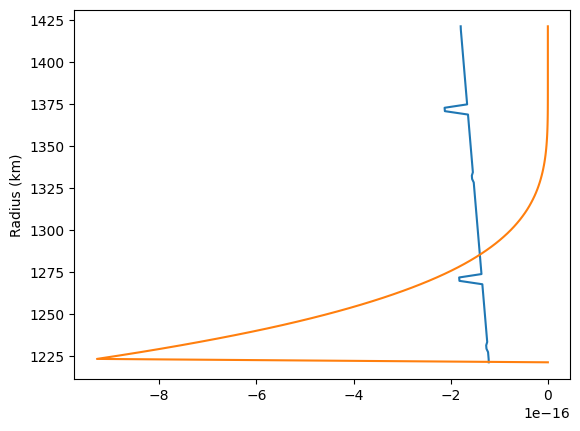

In [6]:
fig, axs = plt.subplots()

axs.plot(lhs, output_data["profiles"].radius/1000.0)
axs.plot(rhs, output_data["profiles"].radius/1000.0)
axs.set_xlabel("")
axs.set_ylabel("Radius (km)")
plt.show()

$$ \frac{\partial\left(\phi^s \rho^s\right)}{\partial t} + 
    \frac{1}{r^2} \frac{\partial}{\partial r}\left(\phi^s r^2 \rho^s u^s_z\right) = \Gamma^s_{\rho}$$

Assume solution is time independent, integrate both sides, include explicit reference to radial dependence:

$$r^2 \phi^s(r) \rho^s(r) u^s_r(r) = \int_{r_{icb}}^r\Gamma^s_{\rho}(r^{\prime}) r^{\prime^2} \mathrm{d}r^{\prime}$$

So we can find the solid velocity from it's density, volume fraction, and growth rate (all of which are known from the explicit calculation):

$$u^s_r(r) = \frac{1}{r^2 \phi^s(r) \rho^s(r)} \int_{r_{icb}}^r\Gamma^s_{\rho}(r^{\prime}) r^{\prime^2} \mathrm{d}r^{\prime}.$$

The following cells compare this calculation with the velocities of the particles from the explicit calculation.

and $\Gamma = \dot M \rho^S$ from my paper...

... Assumed an impenetrable boundary condition at base - this is where limit of integration comes from. With this condition and in steady state --- solid and liquid velocities have to be of opposite sign and if solid is falling the overall mass production
rate has to be negative.

So us creating solid as we fall implies that the solids should go upwards (which is what we find below), however, our solids fall...

[     0.              0.          37263.08665619  72794.81203806
 106659.90402816 138920.15368129 169633.68727298 198855.34600766
 226637.04753931 253030.21726365 278085.05013121 301854.46937808
 324394.20978371 345754.92823433 365983.86959614 385127.12409461
 403228.99751838 420331.44162881 436474.91681518 451700.04836532
 466046.03757975 479550.48839524 492247.98234786 504173.31346412
 515361.54104872 525845.9977612  535659.85781902 544834.70602714
 553402.09680976 561393.9580294  568840.46925826 575769.5934197
 582208.28623066 588183.61684523 593720.10372785 598840.54144568
 603568.66234217 607927.6733615  611938.02273742 615620.30437935
 618995.82983952 622084.22656553 624903.16183443 627470.44214421
 629802.67900982 631914.8270177  633823.74290742 635545.61644267
 637093.53188095 638479.48709087 639716.34484108 640816.99202328
 641793.51054265 642656.09004965 643414.5170691  644078.89093822
 644657.70506327 645159.01957631 645590.89114055 645960.28788217
 646274.45493745 646539.99

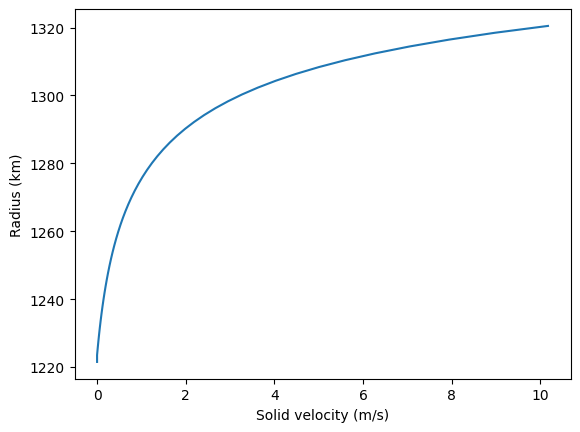

In [7]:
from data_models import solution_profiles

def implied_solid_velocity(profiles: solution_profiles) -> tuple[np.ndarray, np.ndarray]:
    
    # Basically the same thing for liquid, so make it work for both?

    # Local names for ease - these are all np arrays
    radius = profiles.radius
    prod_rate = profiles.mass_fraction_solid_production_rate # But this is mass frac... not mass...
    density = profiles.solid_density
    volume_fraction = profiles.solid_volume_fraction
    integrated_prod_rate = np.zeros_like(radius)
    velocity = np.zeros_like(radius)

    finite_vf = volume_fraction > 0.0 # Don't do the calculation if we have no solid
    # Calculation of solid velocity from time independent integral 
    # of Wilczynski 2025 e.q. 2.1a. Mass production rate is mass fraction production
    # rate multiplied by density (e.g. see Walker 2025 e.g. 5.8)

    gamma = prod_rate * density


    integrated_prod_rate[finite_vf] = sp.integrate.cumulative_trapezoid(
        gamma[finite_vf] * radius[finite_vf]**2, radius[finite_vf], initial=0.0)

    print(integrated_prod_rate)
    velocity[finite_vf] =  integrated_prod_rate[finite_vf] / (radius[finite_vf]**2 * volume_fraction[finite_vf] * density[finite_vf])

    return radius, velocity


radius, velocity = implied_solid_velocity(output_data["profiles"])


fig, axs = plt.subplots()
axs.plot(velocity[0:50], radius[0:50]/1000.0)
axs.set_xlabel("Solid velocity (m/s)")
axs.set_ylabel("Radius (km)")
plt.show()

In [8]:
output_data["profiles"].radius

array([1221500.        , 1223520.2020202 , 1225540.4040404 ,
       1227560.60606061, 1229580.80808081, 1231601.01010101,
       1233621.21212121, 1235641.41414141, 1237661.61616162,
       1239681.81818182, 1241702.02020202, 1243722.22222222,
       1245742.42424242, 1247762.62626263, 1249782.82828283,
       1251803.03030303, 1253823.23232323, 1255843.43434343,
       1257863.63636364, 1259883.83838384, 1261904.04040404,
       1263924.24242424, 1265944.44444444, 1267964.64646465,
       1269984.84848485, 1272005.05050505, 1274025.25252525,
       1276045.45454545, 1278065.65656566, 1280085.85858586,
       1282106.06060606, 1284126.26262626, 1286146.46464646,
       1288166.66666667, 1290186.86868687, 1292207.07070707,
       1294227.27272727, 1296247.47474747, 1298267.67676768,
       1300287.87878788, 1302308.08080808, 1304328.28282828,
       1306348.48484848, 1308368.68686869, 1310388.88888889,
       1312409.09090909, 1314429.29292929, 1316449.49494949,
       1318469.6969697 ,

In [9]:
output_data["profiles"].mass_fraction_solid_production_rate

array([0.00000000e+00, 9.28281232e-16, 8.82521204e-16, 8.38613325e-16,
       7.96543505e-16, 7.56153601e-16, 7.17390286e-16, 6.80116611e-16,
       6.44304469e-16, 6.09931563e-16, 5.76935448e-16, 5.45481318e-16,
       5.15509982e-16, 4.86814913e-16, 4.59417509e-16, 4.33219289e-16,
       4.08212944e-16, 3.84275179e-16, 3.61439674e-16, 3.39660822e-16,
       3.18899322e-16, 2.99102664e-16, 2.80167679e-16, 2.62190460e-16,
       2.45070879e-16, 2.28829890e-16, 2.13407621e-16, 1.98762054e-16,
       1.84935690e-16, 1.71888537e-16, 1.59568476e-16, 1.47915810e-16,
       1.36933145e-16, 1.26610979e-16, 1.16834969e-16, 1.07632954e-16,
       9.90081808e-17, 9.09243542e-17, 8.32881093e-17, 7.61901034e-17,
       6.95621896e-17, 6.33910227e-17, 5.75977420e-17, 5.22595824e-17,
       4.72413154e-17, 4.26005961e-17, 3.83543751e-17, 3.44508222e-17,
       3.08044400e-17, 2.74496439e-17, 2.43835256e-17, 2.16049293e-17,
       1.90764994e-17, 1.67523227e-17, 1.46575607e-17, 1.27763082e-17,
      

We also know the velocity and volume of each particle so we ought to be able to calculate $u^s_r(r)$ from the
explicit calculation. Following Bercovichi et al. (2001 equation 3) and Ni and Beckermann (1991 equations 1-12), I think we can write:

$$ u^s_r(r) = \frac{1}{V^s} \int_{V_0} X^s \tilde{u}_r^s \mathrm{d}V$$

X is this phase function thing, V is the representative volume ...


$$\sum_{i=0}^m \tilde{n}^i \frac{4}{3}\pi  \tilde{r_p}^i \tilde{u}_r^i $$

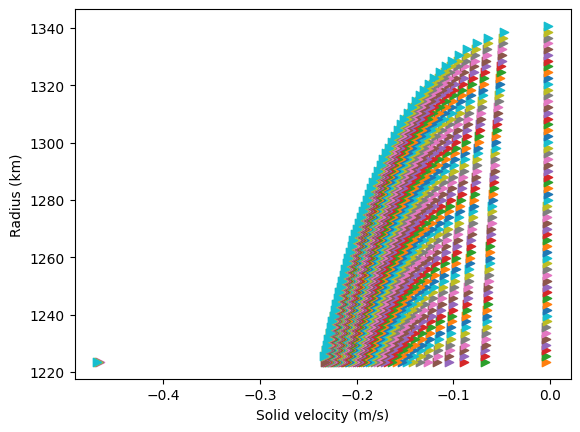

In [10]:
r = output_data["particle_histograms"].radius
rn = output_data["particle_histograms"].nuc_radius
v = output_data["particle_histograms"].particle_velocity

novel = v == 0.0
v[novel] = np.nan

fig, axs = plt.subplots()
for i, rns in enumerate(rn[0:60]):
    axs.scatter(v[:,i], r/1000.0, marker='>')
axs.set_xlabel("Solid velocity (m/s)")
axs.set_ylabel("Radius (km)")
plt.show()



In [11]:
import particle_evolution
import earth_model as em
prem = em.Prem()

def recalculate_rates(input_data, output_data, cases_dict):
    """
    Recalculate the particle falling velocities and growth velocities at each analysis point

    The raw results from our calculation (which includes the radius and position of each 
    particle expressed as piecewise third order polynomials encoded in the solution objects)
    does not allow us to evaluate the falling velocity or growth rate accurately enough to 
    figure out the macroscopic phase weighted velocity using finite difference. Instead, this
    function takes the solutions and, at each analysis point, uses the self-consistent functions
    used to evaluate the growth rate and falling velocity as input to the IVP solver, and recalculates
    these derivatives.

    Note that the input arguments contain almost everything from the calculation. We really need
    to do some code cleanup. Maybe we should use this approach inside the main calculation too.
    """
    # Get hold of the key parameters we need - this is pants
    dl = output_data["chemical_diffusivity"]
    mu = output_data["kinematic_viscosity"]
    k0 = output_data["growth_prefactor"]
    icbr = 1221500.0
    brunt_vaisala = np.sqrt(cases_dict["N2"])[0]

    # Profiles of properties (at each analysis radius)
    calculated_profiles = output_data["profiles"]

    # Setup output arrays
    analysis_radii = output_data["particle_histograms"].radius
    nucleation_radii = output_data["particle_histograms"].nuc_radius
    growth_rate = np.zeros((analysis_radii.shape[0], nucleation_radii.shape[0]), dtype=np.float64)
    falling_rate = np.zeros((analysis_radii.shape[0], nucleation_radii.shape[0]), dtype=np.float64)

    # Now we loop over all our particle trajectories (which start at particular nucleation_radii) and
    # calculate the growth and falling rate for each one at each analysis_radii
    for i, rn in enumerate(nucleation_radii):
        # Grab the right solution object
        solution = output_data['solutions'][i]
        for j, ra in enumerate(analysis_radii):
            # Pressure, temperature etc.
            temperature = output_data["profiles"].temperature[j]
            pressure = output_data["profiles"].pressure[j]
            xliq = output_data["profiles"].liquid_composition[j]
            grav = prem.gravity(ra/1000.0)
            # Grab the particle position, radius and time
            if solution is not None:
                y_event = solution.y_events[j+2] # +2 to skip the terminating events
                t_event = solution.t_events[j+2]
                if y_event.shape == (1, 2):
                    event_time = t_event[0]
                    event_radius = y_event[0,0]
                    event_position = y_event[0,1]
                    # We have some v.small differences in the position recorded
                    # in the event and the analysis radii so check for almost equal
                    np.testing.assert_almost_equal(event_position, ra, 
                        err_msg="event analysis mismatch")
                    # Now we can recalculate the derivatives
                    dy_by_dt = particle_evolution._derivatives_of_ode(
                        event_time, [event_radius, event_position], xliq, 
                        temperature, pressure, dl, k0, grav, mu, icbr, 
                        brunt_vaisala, verbose=True)
                    growth_rate[j, i] = dy_by_dt[0]
                    falling_rate[j, i] = dy_by_dt[1]

        

    return growth_rate, falling_rate

In [12]:

growth_rate, falling_rate = recalculate_rates(input_data, output_data, cases_dict)


Derivative evaluation at 49.985245782023924 s, at z= 1223520.202020202 , rp =  3.2229216377914995e-05
At this point T = 5047.499688467467 K, P = 328.99445556729273 GPa, xl = 0.8381241710029608 (mol frac Fe), g = 4.409175358635188 m/s^2
 dz/dt= -3.167221844413765e-05 , drp/dt =  2.5834914207933934e-07 delta= 6.445843275582999e-05 xp= 0.8243956752466864
Derivative evaluation at 53289.8788812325 s, at z= 1223520.202020202 , rp =  0.0043412688632554625
At this point T = 5047.499688467467 K, P = 328.99445556729273 GPa, xl = 0.8381241710029608 (mol frac Fe), g = 4.409175358635188 m/s^2
 dz/dt= -0.0675518615691058 , drp/dt =  7.076252916959902e-08 delta= 0.00023533490307593998 xp= 0.8243956742157155
Derivative evaluation at 50.12387232728386 s, at z= 1225540.4040404041 , rp =  3.208501534467014e-05
At this point T = 5047.48188695692 K, P = 328.8877626508238 GPa, xl = 0.8381216840118373 (mol frac Fe), g = 4.415228789893099 m/s^2
 dz/dt= -3.143727309967525e-05 , drp/dt =  2.5660328861754067e-07

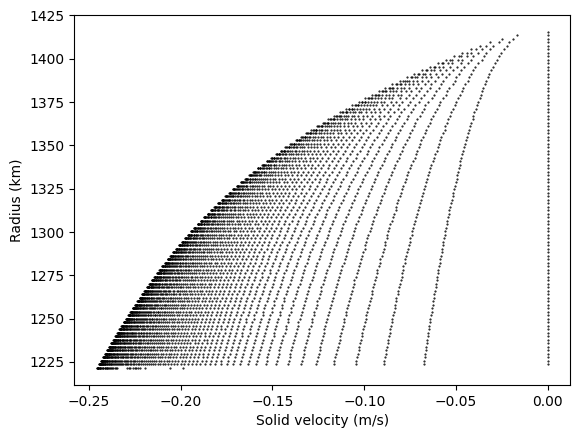

In [13]:
r = output_data["particle_histograms"].radius
rn = output_data["particle_histograms"].nuc_radius
v = falling_rate

novel = v == 0.0
v[novel] = np.nan

fig, axs = plt.subplots()
for i, rns in enumerate(rn):
    axs.scatter(v[:,i], r/1000.0, marker='.', color='k', s=1)
axs.set_xlabel("Solid velocity (m/s)")
axs.set_ylabel("Radius (km)")
plt.show()

In [14]:
output_data["particle_histograms"].radius

array([1221500.        , 1223520.2020202 , 1225540.4040404 ,
       1227560.60606061, 1229580.80808081, 1231601.01010101,
       1233621.21212121, 1235641.41414141, 1237661.61616162,
       1239681.81818182, 1241702.02020202, 1243722.22222222,
       1245742.42424242, 1247762.62626263, 1249782.82828283,
       1251803.03030303, 1253823.23232323, 1255843.43434343,
       1257863.63636364, 1259883.83838384, 1261904.04040404,
       1263924.24242424, 1265944.44444444, 1267964.64646465,
       1269984.84848485, 1272005.05050505, 1274025.25252525,
       1276045.45454545, 1278065.65656566, 1280085.85858586,
       1282106.06060606, 1284126.26262626, 1286146.46464646,
       1288166.66666667, 1290186.86868687, 1292207.07070707,
       1294227.27272727, 1296247.47474747, 1298267.67676768,
       1300287.87878788, 1302308.08080808, 1304328.28282828,
       1306348.48484848, 1308368.68686869, 1310388.88888889,
       1312409.09090909, 1314429.29292929, 1316449.49494949,
       1318469.6969697 ,

In [18]:
print(falling_rate[1,:])

[            nan -3.16722184e-05 -6.75518616e-02 -8.93843709e-02
 -1.04650801e-01 -1.16677588e-01 -1.26418257e-01 -1.34674732e-01
 -1.41664698e-01 -1.48055432e-01 -1.53572208e-01 -1.58732657e-01
 -1.63263648e-01 -1.67539034e-01 -1.71277701e-01 -1.74840939e-01
 -1.78123219e-01 -1.81355870e-01 -1.84008158e-01 -1.86668799e-01
 -1.89239758e-01 -1.91551070e-01 -1.93830063e-01 -1.96002876e-01
 -1.98018933e-01 -2.00028230e-01 -2.01762974e-01 -2.03684513e-01
 -2.05126034e-01 -2.06673559e-01 -2.08423596e-01 -2.09729332e-01
 -2.11184417e-01 -2.12578565e-01 -2.13822523e-01 -2.15025672e-01
 -2.16214190e-01 -2.17486822e-01 -2.18451148e-01 -2.19576024e-01
 -2.20629941e-01 -2.21658167e-01 -2.22628294e-01 -2.23366111e-01
 -2.24276361e-01 -2.25337066e-01 -2.26149249e-01 -2.26806429e-01
 -2.27556328e-01 -2.28521782e-01 -2.29245183e-01 -2.30030897e-01
 -2.30548923e-01 -2.31316716e-01 -2.31778764e-01 -2.32427470e-01
 -2.33128320e-01 -2.33742893e-01 -2.34052398e-01 -2.34696877e-01
 -2.35165287e-01 -2.35769

In [17]:
print(output_data["particle_histograms"].particle_velocity[1,:])

[            nan -4.21770950e-03 -6.75274307e-02 -8.93541992e-02
 -1.04624702e-01 -1.16639252e-01 -1.26413197e-01 -1.34637896e-01
 -1.41652350e-01 -1.48036848e-01 -1.53574521e-01 -1.58748844e-01
 -1.63288843e-01 -1.67497246e-01 -1.71292808e-01 -1.74787986e-01
 -1.78174740e-01 -1.81313028e-01 -1.83999334e-01 -1.86669454e-01
 -1.89237779e-01 -1.91596956e-01 -1.93795748e-01 -1.96054904e-01
 -1.98042547e-01 -2.00017372e-01 -2.01782208e-01 -2.03687742e-01
 -2.05094953e-01 -2.06633050e-01 -2.08372585e-01 -2.09702153e-01
 -2.11079945e-01 -2.12551984e-01 -2.13810783e-01 -2.15039908e-01
 -2.16201721e-01 -2.17516261e-01 -2.18434408e-01 -2.19575328e-01
 -2.20553045e-01 -2.21554845e-01 -2.22618317e-01 -2.23431364e-01
 -2.24283006e-01 -2.25263113e-01 -2.26133373e-01 -2.26862908e-01
 -2.27535170e-01 -2.28533912e-01 -2.29231335e-01 -2.30001203e-01
 -2.30470823e-01 -2.31220874e-01 -2.31713316e-01 -2.32418463e-01
 -4.65478619e-01 -4.66455619e-01 -4.67257052e-01 -4.68531494e-01
 -4.69382311e-01 -4.70661